In [ ]:
# Install dependencies
!pip install torch torchvision opencv-python pillow matplotlib tqdm ultralytics kagglehub torchmetrics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 43.0 MB/s eta 0:00:00


In [ ]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
import kagglehub
from tqdm import tqdm
import torch.nn.functional as F

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")


Device: cuda


In [ ]:
# Download CelebA
path = kagglehub.dataset_download("jessicali9530/celeba-dataset")
print(path)


Using Colab cache for faster access to the 'celeba-dataset' dataset.
/kaggle/input/celeba-dataset


In [ ]:
import matplotlib.patches as patches
base_path = path
img_folder = os.path.join(base_path, "img_align_celeba/img_align_celeba")


def prepare_dataset(source_path, output_path, fraction=0.3, image_size=64, batch_size=64):
    """
    Batched YOLO inference: passes `batch_size` images to YOLO at once instead of
    one-by-one — reduces Python/CUDA overhead ~10-20x over the sequential version.
    Falls back to a center crop when YOLO finds no face (rare in img_align_celeba).
    """
    from ultralytics import YOLO as _YOLO

    for split in ['train', 'val', 'test']:
        os.makedirs(os.path.join(output_path, split, 'images'), exist_ok=True)

    partition_df = pd.read_csv(os.path.join(source_path, 'list_eval_partition.csv'))
    yolo = _YOLO('yolov8n.pt')

    transform = transforms.Compose([
        transforms.Resize([image_size, image_size]),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])
    center_crop = transforms.Compose([
        transforms.CenterCrop(min(178, 218)),
        transforms.Resize([image_size, image_size]),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])

    img_source_path = os.path.join(source_path, 'img_align_celeba/img_align_celeba')

    for split_name, partition_id in [('train', 0), ('val', 1), ('test', 2)]:
        split_df = partition_df[partition_df['partition'] == partition_id].reset_index(drop=True)
        split_df = split_df[:int(len(split_df) * fraction)]
        out_dir = os.path.join(output_path, split_name, 'images')

        names = split_df['image_id'].tolist()
        for batch_start in tqdm(range(0, len(names), batch_size), desc=split_name):
            batch_names = names[batch_start:batch_start + batch_size]
            batch_paths = [os.path.join(img_source_path, n) for n in batch_names]
            imgs = [Image.open(p).convert('RGB') for p in batch_paths]

            results = yolo(imgs, verbose=False)

            for i, (img, result) in enumerate(zip(imgs, results)):
                idx = batch_start + i
                if len(result.boxes) > 0:
                    x1, y1, x2, y2 = result.boxes.xyxy[0].cpu().numpy().astype(int)
                    crop = img.crop((x1, y1, x2, y2))
                    tensor = transform(crop)
                else:
                    tensor = center_crop(img)
                torch.save(tensor, os.path.join(out_dir, f'{idx:06d}.pt'))

    print(f"Dataset prepared in {output_path}")


def create_attributes_file(source_path, output_path, train_fraction=0.3):
    partition_df = pd.read_csv(os.path.join(source_path, 'list_eval_partition.csv'))
    attr_df = pd.read_csv(os.path.join(source_path, 'list_attr_celeba.csv'))

    for split_name, partition_id in [('train', 0), ('val', 1), ('test', 2)]:
        split_df = partition_df[partition_df['partition'] == partition_id].reset_index(drop=True)
        if split_name == 'train':
            split_df = split_df[:int(len(split_df) * train_fraction)]

        img_dir = os.path.join(output_path, split_name, 'images')
        processed_files = [f for f in os.listdir(img_dir) if f.endswith('.pt')]
        processed_indices = [int(f.replace('.pt', '')) for f in processed_files]
        processed_names = split_df.iloc[processed_indices]['image_id'].tolist()

        split_attr = attr_df[attr_df['image_id'].isin(processed_names)][['image_id', 'Male']].copy()
        split_attr['Male'] = (split_attr['Male'] + 1) // 2
        split_attr.to_csv(os.path.join(output_path, split_name, 'attributes.csv'), index=False)
        print(f"{split_name}: {len(split_attr)} attributes")


PROCESSED_DATA_PATH = '/content/data_set'

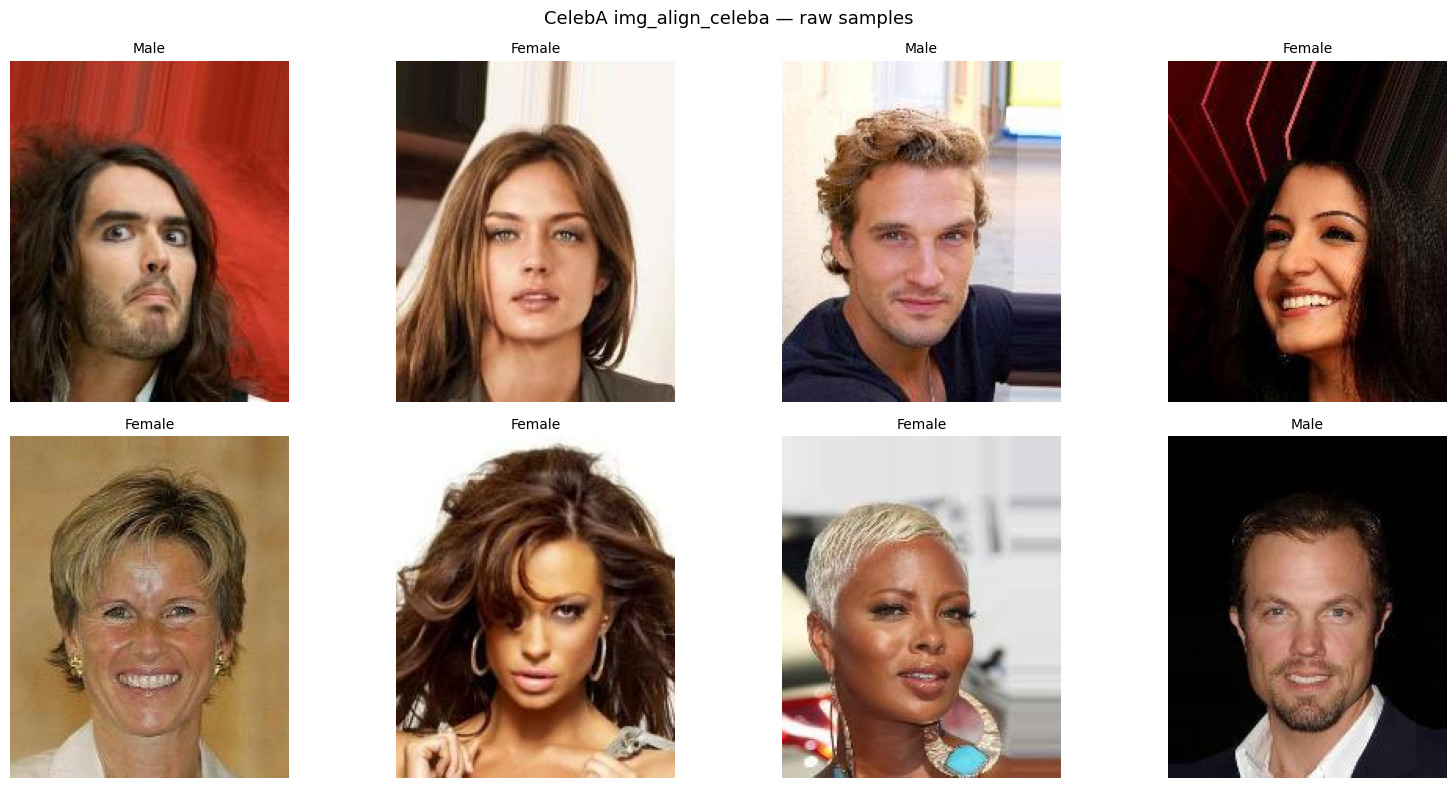

In [ ]:
# ─── Visualisation 1: raw CelebA samples + gender labels ─────────────────────
attr_df_vis = pd.read_csv(os.path.join(base_path, 'list_attr_celeba.csv'))
sample_imgs_names = attr_df_vis['image_id'].sample(8, random_state=42).tolist()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, img_name in zip(axes.flat, sample_imgs_names):
    img = Image.open(os.path.join(img_folder, img_name)).convert('RGB')
    gender = attr_df_vis[attr_df_vis['image_id'] == img_name]['Male'].values[0]
    ax.imshow(img)
    ax.set_title(f"{'Male' if gender == 1 else 'Female'}", fontsize=10)
    ax.axis('off')
plt.suptitle("CelebA img_align_celeba — raw samples", fontsize=13)
plt.tight_layout()
plt.show()


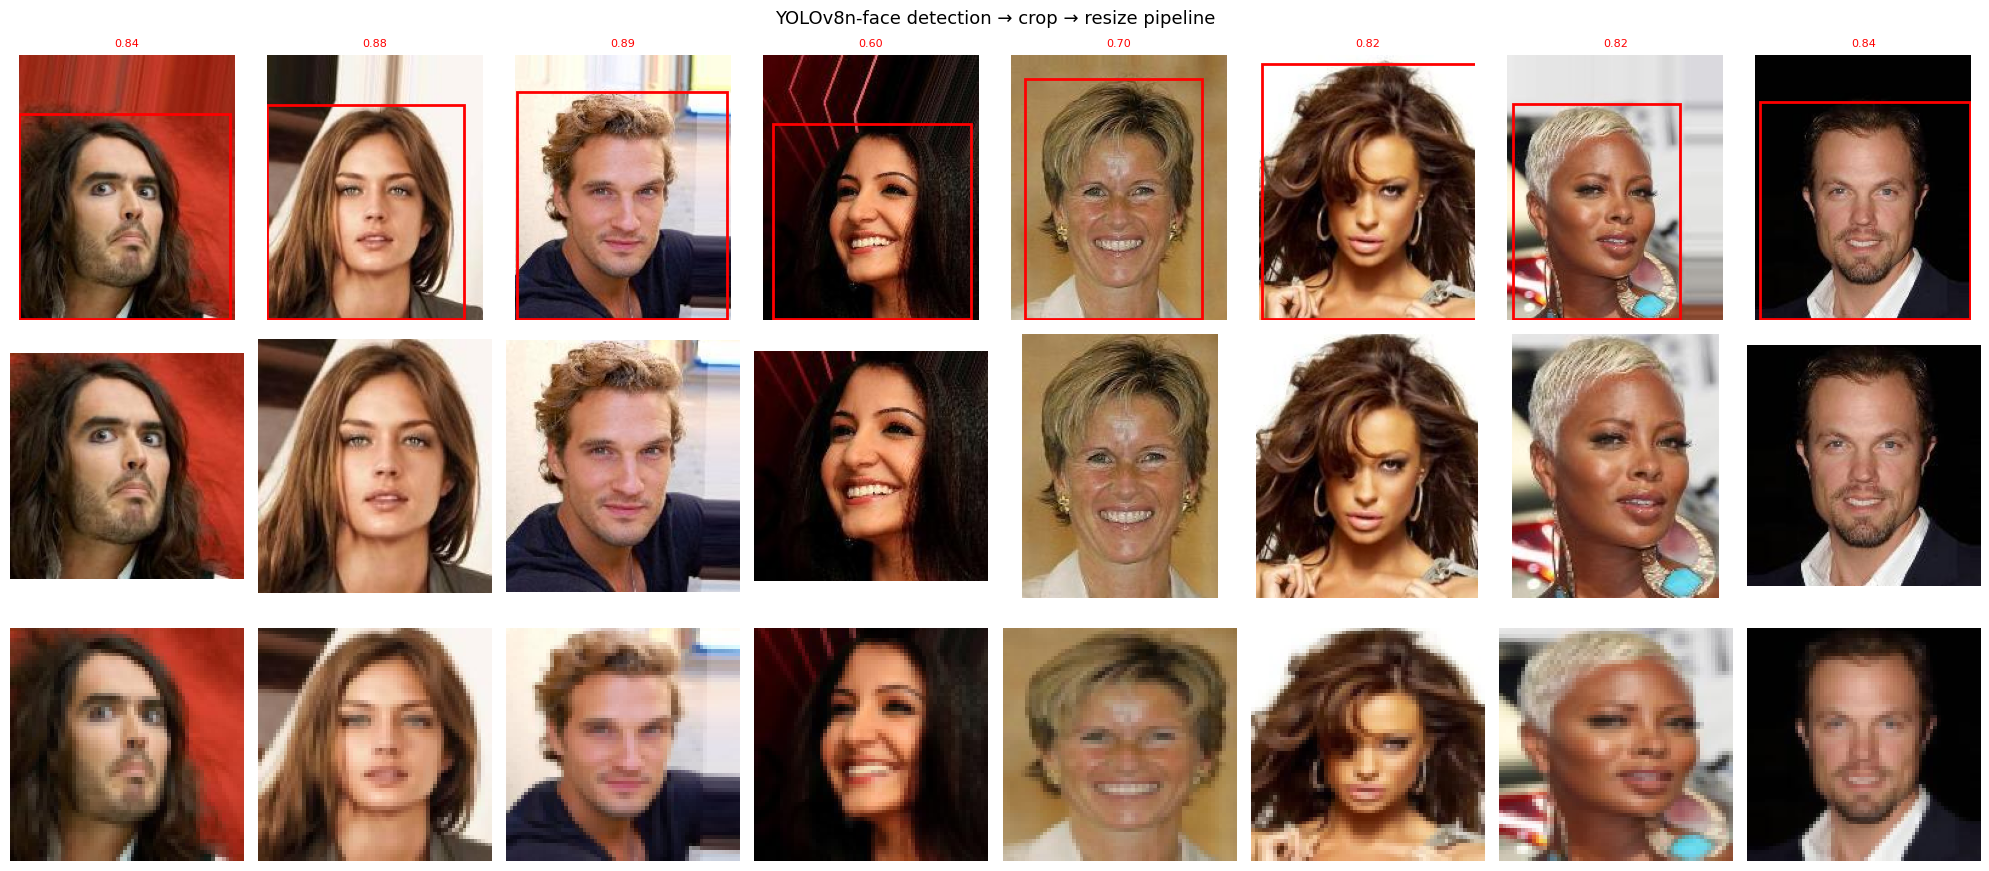

In [ ]:
# ─── Visualisation 2: YOLOv8n-face detection + crop pipeline ─────────────────
from ultralytics import YOLO

yolo_demo = YOLO('yolov8n.pt')
demo_paths = [os.path.join(img_folder, n) for n in sample_imgs_names]
yolo_results = yolo_demo(demo_paths, verbose=False)

# Row 1: original with detected bbox drawn
# Row 2: YOLO crop resized to 64×64 (exactly what prepare_dataset saves)
fig, axes = plt.subplots(3, 8, figsize=(20, 9))
for col, (result, img_path, img_name) in enumerate(zip(yolo_results, demo_paths, sample_imgs_names)):
    img = Image.open(img_path).convert('RGB')

    # original + box
    axes[0, col].imshow(img)
    if len(result.boxes) > 0:
        x1, y1, x2, y2 = result.boxes.xyxy[0].cpu().numpy().astype(int)
        conf = result.boxes.conf[0].item()
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                  linewidth=2, edgecolor='red', facecolor='none')
        axes[0, col].add_patch(rect)
        axes[0, col].set_title(f"{conf:.2f}", fontsize=8, color='red')
        crop = img.crop((x1, y1, x2, y2))
    else:
        w, h = img.size
        m = min(w, h)
        crop = img.crop(((w-m)//2, (h-m)//2, (w+m)//2, (h+m)//2))
        axes[0, col].set_title("no det", fontsize=8)
    axes[0, col].axis('off')

    # YOLO crop
    axes[1, col].imshow(crop)
    axes[1, col].axis('off')

    # final 64×64
    axes[2, col].imshow(crop.resize((64, 64), Image.BILINEAR))
    axes[2, col].axis('off')

axes[0, 0].set_ylabel("Original +\nYOLO box", fontsize=9)
axes[1, 0].set_ylabel("Face crop", fontsize=9)
axes[2, 0].set_ylabel("64×64 input", fontsize=9)
plt.suptitle("YOLOv8n-face detection → crop → resize pipeline", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
prepare_dataset(base_path, PROCESSED_DATA_PATH)
create_attributes_file(base_path, PROCESSED_DATA_PATH)

test: 100%|██████████| 94/94 [00:56<00:00,  1.67it/s]


Dataset prepared in /content/data_set
train: 48831 attributes
val: 5960 attributes
test: 5988 attributes


In [ ]:
class ProcessedCelebADataset(Dataset):
    def __init__(self, data_path, split='train', attributes=None):
        self.img_path = os.path.join(data_path, split, 'images')
        self.img_files = sorted([f for f in os.listdir(self.img_path) if f.endswith('.pt')])

        if attributes is not None:
            attr_path = os.path.join(data_path, split, 'attributes.csv')
            self.attr_df = pd.read_csv(attr_path)[['image_id'] + attributes]
            self.use_attributes = True
        else:
            self.attr_df = None
            self.use_attributes = False

        print(f"Loaded {split}: {len(self.img_files)} images")

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        image = torch.load(os.path.join(self.img_path, self.img_files[idx]), weights_only=True)
        if self.use_attributes:
            attrs = self.attr_df.iloc[idx, 1:].values.astype('float32')
            return image, torch.tensor(attrs)
        return image



Loaded train: 48831 images


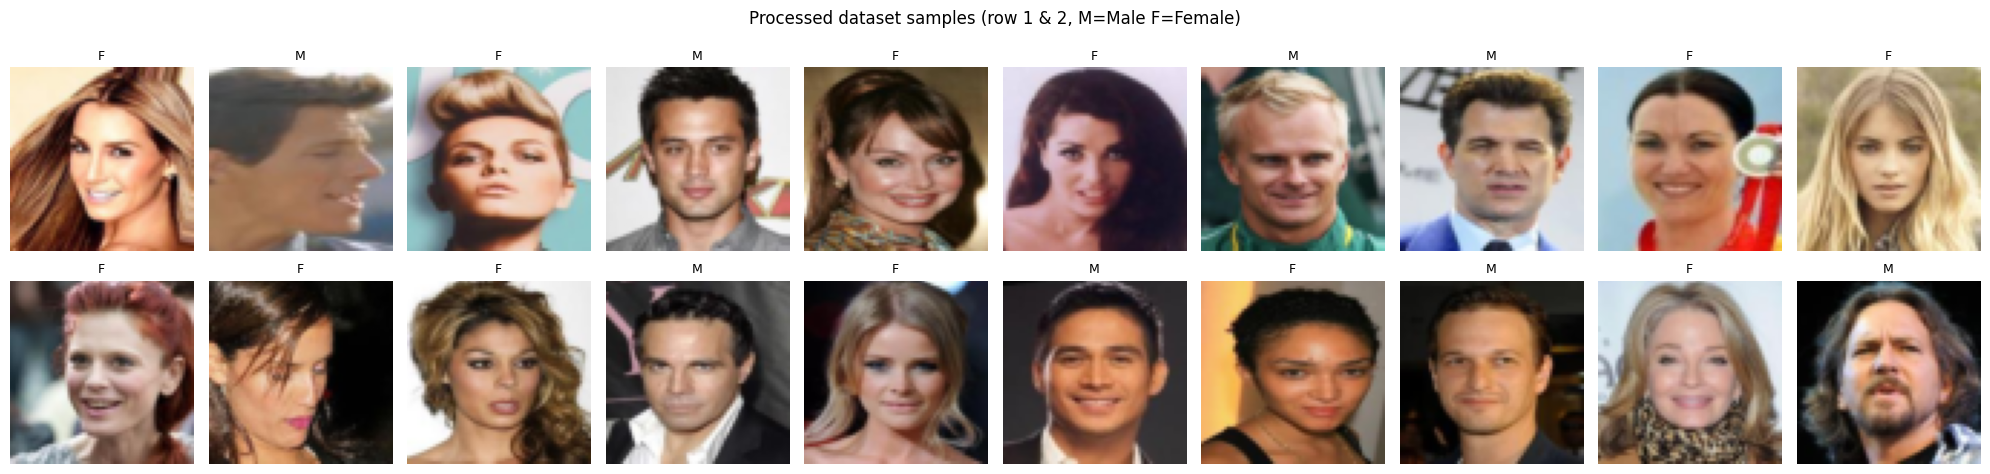

In [ ]:
# ─── Visualisation 3: processed dataset sample grid with gender labels ────────
_ds_check = ProcessedCelebADataset(PROCESSED_DATA_PATH, split='train', attributes=['Male'])
fig, axes = plt.subplots(2, 10, figsize=(20, 5))
for col in range(10):
    img_f, lbl_f = _ds_check[col * 2]
    img_m, lbl_m = _ds_check[col * 2 + 1]
    for ax, img, lbl in [(axes[0, col], img_f, lbl_f), (axes[1, col], img_m, lbl_m)]:
        ax.imshow((img.permute(1, 2, 0) * 0.5 + 0.5).clamp(0, 1))
        ax.set_title(f"{'M' if int(lbl[0]) else 'F'}", fontsize=9)
        ax.axis('off')
plt.suptitle("Processed dataset samples (row 1 & 2, M=Male F=Female)", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# ─── Perceptual loss (VGG16 feature matching) ────────────────────────────────
# Fixes the main blurriness problem of MSE-only VAE losses.

class PerceptualLoss(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = models.vgg16(weights=models.VGG16_Weights.DEFAULT).features
        # Use relu1_2, relu2_2, relu3_3 feature maps
        self.slices = nn.ModuleList([
            vgg[:4],   # relu1_2
            vgg[4:9],  # relu2_2
            vgg[9:16], # relu3_3
        ])
        for p in self.parameters():
            p.requires_grad = False

    def forward(self, x, y):
        # Rescale from [-1,1] to ImageNet range
        mean = torch.tensor([0.485, 0.456, 0.406], device=x.device).view(1, 3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225], device=x.device).view(1, 3, 1, 1)
        x = (x * 0.5 + 0.5 - mean) / std
        y = (y * 0.5 + 0.5 - mean) / std
        loss = 0.0
        for s in self.slices:
            x = s(x)
            y = s(y)
            loss = loss + F.mse_loss(x, y)
        return loss



In [ ]:
# ─── Convolutional VAE ────────────────────────────────────────────────────────
# Conv encoder → mu/logvar → reparameterize → ConvTranspose decoder.
# Result: spatially coherent reconstructions, no grid artifacts.

class ResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(channels, channels, 3, 1, 1),
            nn.GroupNorm(8, channels),
            nn.SiLU(),
            nn.Conv2d(channels, channels, 3, 1, 1),
            nn.GroupNorm(8, channels),
        )
        self.act = nn.SiLU()

    def forward(self, x):
        return self.act(x + self.net(x))


class ConvVAE(nn.Module):
    def __init__(self, latent_dim=256, img_channels=3, img_size=64):
        super().__init__()
        self.latent_dim = latent_dim

        # Encoder: 64→32→16→8→4 (stride-2 conv)
        self.encoder = nn.Sequential(
            nn.Conv2d(img_channels, 64, 4, 2, 1),   # 32×32
            nn.SiLU(),
            nn.Conv2d(64, 128, 4, 2, 1),             # 16×16
            nn.GroupNorm(8, 128), nn.SiLU(),
            nn.Conv2d(128, 256, 4, 2, 1),            # 8×8
            nn.GroupNorm(8, 256), nn.SiLU(),
            ResBlock(256),
            nn.Conv2d(256, 512, 4, 2, 1),            # 4×4
            nn.GroupNorm(8, 512), nn.SiLU(),
            ResBlock(512),
        )
        self.fc_mu = nn.Linear(512 * 4 * 4, latent_dim)
        self.fc_logvar = nn.Linear(512 * 4 * 4, latent_dim)

        # Decoder: latent → 4→8→16→32→64
        self.fc_decode = nn.Linear(latent_dim, 512 * 4 * 4)
        self.decoder = nn.Sequential(
            ResBlock(512),
            nn.ConvTranspose2d(512, 256, 4, 2, 1),  # 8×8
            nn.GroupNorm(8, 256), nn.SiLU(),
            ResBlock(256),
            nn.ConvTranspose2d(256, 128, 4, 2, 1),  # 16×16
            nn.GroupNorm(8, 128), nn.SiLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),   # 32×32
            nn.GroupNorm(8, 64), nn.SiLU(),
            nn.ConvTranspose2d(64, img_channels, 4, 2, 1),  # 64×64
            nn.Tanh(),
        )

    def encode(self, x):
        h = self.encoder(x).flatten(1)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        return mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)

    def decode(self, z):
        h = self.fc_decode(z).view(z.size(0), 512, 4, 4)
        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


def vae_loss(x_recon, x, mu, logvar, beta=1.0, perceptual_fn=None):
    recon_loss = F.mse_loss(x_recon, x, reduction='sum')
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    total = recon_loss + beta * kl_loss
    if perceptual_fn is not None:
        total = total + 10.0 * perceptual_fn(x_recon, x) * x.size(0)
    return total, recon_loss, kl_loss


def train_vae(model, dataloader, epochs=25, lr=1e-4, device='cuda'):
    """
    Uses:
    - Convolutional encoder/decoder
    - Perceptual loss to reduce blurriness
    - Beta annealing: start small, ramp up to 1.0 to avoid KL collapse
    """
    model = model.to(device)
    perc = PerceptualLoss().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, epochs)

    history = {'total_loss': [], 'recon_loss': [], 'kl_loss': []}

    for epoch in range(epochs):
        model.train()
        # Beta warm-up over first 10 epochs to avoid KL collapse
        beta = min(1.0, (epoch + 1) / 10.0)
        total_loss, recon_loss, kl_loss = 0.0, 0.0, 0.0

        for batch in tqdm(dataloader, desc=f"VAE Epoch {epoch+1}"):
            x = batch[0].to(device) if isinstance(batch, (list, tuple)) else batch.to(device)

            optimizer.zero_grad()
            x_recon, mu, logvar = model(x)
            loss, r, k = vae_loss(x_recon, x, mu, logvar, beta=beta, perceptual_fn=perc)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_loss += loss.item()
            recon_loss += r.item()
            kl_loss += k.item()

        n = len(dataloader.dataset)
        history['total_loss'].append(total_loss / n)
        history['recon_loss'].append(recon_loss / n)
        history['kl_loss'].append(kl_loss / n)
        print(f"Epoch {epoch+1}: Loss={total_loss/n:.4f}  Recon={recon_loss/n:.4f}  KL={kl_loss/n:.4f}  β={beta:.2f}")
        scheduler.step()

    return history



In [ ]:
train_dataset = ProcessedCelebADataset(data_path=PROCESSED_DATA_PATH, split='train')
val_dataset = ProcessedCelebADataset(data_path=PROCESSED_DATA_PATH, split='val')
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)

model_vae = ConvVAE(latent_dim=256, img_channels=3, img_size=64)
history_vae = train_vae(model_vae, train_loader, epochs=25, lr=1e-4, device=device)

torch.save({'model_state_dict': model_vae.state_dict(), 'history': history_vae}, 'conv_vae.pth')


Loaded train: 48831 images
Loaded val: 5960 images
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:05<00:00, 103MB/s] 
VAE Epoch 1: 100%|██████████| 763/763 [01:55<00:00,  6.63it/s]


Epoch 1: Loss=1333.9266  Recon=952.8301  KL=404.5144  β=0.10


VAE Epoch 2: 100%|██████████| 763/763 [01:53<00:00,  6.73it/s]


Epoch 2: Loss=814.8619  Recon=454.7604  KL=399.8529  β=0.20


VAE Epoch 3:  21%|██▏       | 164/763 [00:24<01:25,  7.01it/s]

In [ ]:
# Load and visualize unconditional VAE samples
model_vae = ConvVAE(latent_dim=256)
model_vae.to(device)
ck = torch.load('conv_vae.pth', weights_only=True)
model_vae.load_state_dict(ck['model_state_dict'])
history_vae = ck['history']

model_vae.eval()
with torch.no_grad():
    z = torch.randn(16, 256).to(device)
    samples = model_vae.decode(z).cpu().permute(0, 2, 3, 1) * 0.5 + 0.5

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(samples[i].clamp(0, 1))
    ax.axis('off')
plt.suptitle("Unconditional ConvVAE samples")
plt.tight_layout()
plt.show()


In [ ]:
# Training curves — VAE
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, key, title in zip(axes, ['total_loss', 'recon_loss', 'kl_loss'],
                           ['Total Loss', 'Reconstruction Loss', 'KL Divergence']):
    ax.plot(history_vae[key])
    ax.set_xlabel('Epoch')
    ax.set_ylabel(key)
    ax.set_title(title)
plt.suptitle("ConvVAE Training Curves")
plt.tight_layout()
plt.show()


In [ ]:
# ─── FID / IS — Unconditional VAE ─────────────────────────────────────────────
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore

def compute_metrics(model_fn, val_loader, n_samples=500, device='cuda'):
    fid = FrechetInceptionDistance(feature=2048).to(device)
    inception = InceptionScore().to(device)

    # Real images
    count = 0
    for batch in val_loader:
        x = batch[0].to(device) if isinstance(batch, (list, tuple)) else batch.to(device)
        x = (x * 0.5 + 0.5).clamp(0, 1)
        x = (x * 255).to(torch.uint8)
        fid.update(x, real=True)
        count += x.size(0)
        if count >= n_samples:
            break

    # Generated images
    count = 0
    with torch.no_grad():
        while count < n_samples:
            imgs = model_fn(min(64, n_samples - count))
            imgs = (imgs * 0.5 + 0.5).clamp(0, 1)
            imgs = (imgs * 255).to(torch.uint8)
            fid.update(imgs, real=False)
            inception.update(imgs)
            count += imgs.size(0)

    fid_val = fid.compute().item()
    is_mean, is_std = inception.compute()
    return fid_val, is_mean.item(), is_std.item()


model_vae.eval()
def sample_vae(n):
    z = torch.randn(n, 256, device=device)
    return model_vae.decode(z)

fid_vae, is_mean_vae, is_std_vae = compute_metrics(sample_vae, val_loader, n_samples=500, device=device)
print(f"ConvVAE — FID: {fid_vae:.2f}  IS: {is_mean_vae:.3f} ± {is_std_vae:.3f}")


In [ ]:
# ─── Conditional ConvVAE (gender conditioning) ───────────────────────────────
# Label embedding injected into both encoder (via concat after flatten) and
# decoder (via AdaGN-style: scale/shift the GroupNorm in ResBlocks).
# Simpler approach: embed label → concat with z before decode, and concat
# flattened label embedding with encoder features.

class ConditionalConvVAE(nn.Module):
    def __init__(self, latent_dim=256, img_channels=3, img_size=64, num_classes=2):
        super().__init__()
        self.latent_dim = latent_dim
        self.embed = nn.Embedding(num_classes, 64)  # class → 64-dim vector

        # Encoder: same conv stack, class embedding concatenated before mu/logvar projections
        self.encoder = nn.Sequential(
            nn.Conv2d(img_channels, 64, 4, 2, 1),
            nn.SiLU(),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.GroupNorm(8, 128), nn.SiLU(),
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.GroupNorm(8, 256), nn.SiLU(),
            ResBlock(256),
            nn.Conv2d(256, 512, 4, 2, 1),
            nn.GroupNorm(8, 512), nn.SiLU(),
            ResBlock(512),
        )
        self.fc_mu = nn.Linear(512 * 4 * 4 + 64, latent_dim)
        self.fc_logvar = nn.Linear(512 * 4 * 4 + 64, latent_dim)

        self.fc_decode = nn.Linear(latent_dim + 64, 512 * 4 * 4)
        self.decoder = nn.Sequential(
            ResBlock(512),
            nn.ConvTranspose2d(512, 256, 4, 2, 1),
            nn.GroupNorm(8, 256), nn.SiLU(),
            ResBlock(256),
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.GroupNorm(8, 128), nn.SiLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.GroupNorm(8, 64), nn.SiLU(),
            nn.ConvTranspose2d(64, img_channels, 4, 2, 1),
            nn.Tanh(),
        )

    def encode(self, x, label):
        h = self.encoder(x).flatten(1)
        c = self.embed(label)
        h = torch.cat([h, c], dim=1)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        return mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)

    def decode(self, z, label):
        c = self.embed(label)
        h = self.fc_decode(torch.cat([z, c], dim=1)).view(z.size(0), 512, 4, 4)
        return self.decoder(h)

    def forward(self, x, label):
        mu, logvar = self.encode(x, label)
        z = self.reparameterize(mu, logvar)
        return self.decode(z, label), mu, logvar


def train_cvae(model, dataloader, epochs=25, lr=1e-4, device='cuda'):
    model = model.to(device)
    perc = PerceptualLoss().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, epochs)

    history = {'total_loss': [], 'recon_loss': [], 'kl_loss': []}

    for epoch in range(epochs):
        model.train()
        beta = min(1.0, (epoch + 1) / 10.0)
        total_loss, recon_loss, kl_loss = 0.0, 0.0, 0.0

        for batch in tqdm(dataloader, desc=f"CVAE Epoch {epoch+1}"):
            x, attrs = batch[0].to(device), batch[1].to(device)
            # attrs is float [0/1]; convert to long class index
            label = attrs[:, 0].long()

            optimizer.zero_grad()
            x_recon, mu, logvar = model(x, label)
            loss, r, k = vae_loss(x_recon, x, mu, logvar, beta=beta, perceptual_fn=perc)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_loss += loss.item()
            recon_loss += r.item()
            kl_loss += k.item()

        n = len(dataloader.dataset)
        history['total_loss'].append(total_loss / n)
        history['recon_loss'].append(recon_loss / n)
        history['kl_loss'].append(kl_loss / n)
        print(f"Epoch {epoch+1}: Loss={total_loss/n:.4f}  Recon={recon_loss/n:.4f}  KL={kl_loss/n:.4f}  β={beta:.2f}")
        scheduler.step()

    return history



In [ ]:
train_dataset_attr = ProcessedCelebADataset(data_path=PROCESSED_DATA_PATH, split='train', attributes=['Male'])
val_dataset_attr = ProcessedCelebADataset(data_path=PROCESSED_DATA_PATH, split='val', attributes=['Male'])
train_loader_attr = DataLoader(train_dataset_attr, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader_attr = DataLoader(val_dataset_attr, batch_size=64, shuffle=False, num_workers=2)

model_cvae = ConditionalConvVAE(latent_dim=256, num_classes=2)
history_cvae = train_cvae(model_cvae, train_loader_attr, epochs=25, lr=1e-4, device=device)

torch.save({'model_state_dict': model_cvae.state_dict(), 'history': history_cvae}, 'conv_cvae.pth')


In [ ]:
# Load and visualize conditional samples (female / male)
model_cvae = ConditionalConvVAE(latent_dim=256, num_classes=2)
model_cvae.to(device)
ck = torch.load('conv_cvae.pth', weights_only=True)
model_cvae.load_state_dict(ck['model_state_dict'])
history_cvae = ck['history']

model_cvae.eval()
with torch.no_grad():
    fig, axes = plt.subplots(2, 8, figsize=(18, 5))
    for row, (gender, name) in enumerate([(0, 'Female'), (1, 'Male')]):
        label = torch.full((8,), gender, dtype=torch.long, device=device)
        z = torch.randn(8, 256, device=device)
        samples = model_cvae.decode(z, label).cpu().permute(0, 2, 3, 1) * 0.5 + 0.5
        samples = samples.clamp(0, 1)
        for col in range(8):
            axes[row, col].imshow(samples[col])
            axes[row, col].axis('off')
        axes[row, 0].set_ylabel(name, fontsize=13)

plt.suptitle("Conditional ConvVAE — Female (top) vs Male (bottom)")
plt.tight_layout()
plt.show()


In [ ]:
# Latent interpolation — same z seeds, toggle gender
model_cvae.eval()
with torch.no_grad():
    z_base = torch.randn(8, 256, device=device)
    fig, axes = plt.subplots(2, 8, figsize=(18, 5))
    for row, (gender, name) in enumerate([(0, 'Female'), (1, 'Male')]):
        label = torch.full((8,), gender, dtype=torch.long, device=device)
        samples = model_cvae.decode(z_base, label).cpu().permute(0, 2, 3, 1) * 0.5 + 0.5
        for col in range(8):
            axes[row, col].imshow(samples[col].clamp(0, 1))
            axes[row, col].axis('off')
        axes[row, 0].set_ylabel(name, fontsize=13)

plt.suptitle("Same z seeds, gender toggled — demonstrates conditioning")
plt.tight_layout()
plt.show()


In [ ]:
# Training curves — CVAE
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, key, title in zip(axes, ['total_loss', 'recon_loss', 'kl_loss'],
                           ['Total Loss', 'Reconstruction Loss', 'KL Divergence']):
    ax.plot(history_cvae[key])
    ax.set_xlabel('Epoch')
    ax.set_ylabel(key)
    ax.set_title(title)
plt.suptitle("ConditionalConvVAE Training Curves")
plt.tight_layout()
plt.show()


In [ ]:
# ─── FID / IS — Conditional VAE ───────────────────────────────────────────────
model_cvae.eval()

def sample_cvae_female(n):
    z = torch.randn(n, 256, device=device)
    lbl = torch.zeros(n, dtype=torch.long, device=device)
    return model_cvae.decode(z, lbl)

def sample_cvae_male(n):
    z = torch.randn(n, 256, device=device)
    lbl = torch.ones(n, dtype=torch.long, device=device)
    return model_cvae.decode(z, lbl)

fid_female, is_mean_f, is_std_f = compute_metrics(sample_cvae_female, val_loader_attr, n_samples=500, device=device)
fid_male, is_mean_m, is_std_m = compute_metrics(sample_cvae_male, val_loader_attr, n_samples=500, device=device)

print(f"ConditionalConvVAE (Female) — FID: {fid_female:.2f}  IS: {is_mean_f:.3f} ± {is_std_f:.3f}")
print(f"ConditionalConvVAE (Male)   — FID: {fid_male:.2f}  IS: {is_mean_m:.3f} ± {is_std_m:.3f}")
print(f"Avg FID: {(fid_female + fid_male) / 2:.2f}")


In [ ]:
# ─── Summary ──────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("Lab 4 — CelebA Face Generation Results")
print("=" * 60)
print(f"{'Model':<28} {'FID ↓':>8} {'IS ↑':>14}")
print("-" * 60)
print(f"{'ConvVAE (uncond)':<28} {fid_vae:>8.2f} {is_mean_vae:>8.3f}±{is_std_vae:.3f}")
print(f"{'ConvCVAE female':<28} {fid_female:>8.2f} {is_mean_f:>8.3f}±{is_std_f:.3f}")
print(f"{'ConvCVAE male':<28} {fid_male:>8.2f} {is_mean_m:>8.3f}±{is_std_m:.3f}")
print("=" * 60)
